In [1]:
#Q59
import pandas as pd
import numpy as np

In [2]:
data = {
"A": ["TeamA", "TeamB", "TeamB", "TeamC", "TeamA"],
"B": [50, 40, 40, 30, 50],
"C": [True, False, False, False, True]
}
df=pd.DataFrame(data)

In [3]:
df

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
2,TeamB,40,False
3,TeamC,30,False
4,TeamA,50,True


In [9]:
df=df.drop_duplicates().reset_index()
df

,level_0,index,A,B,C
0,0,0,TeamA,50,True
1,1,1,TeamB,40,False
2,2,3,TeamC,30,False


In [14]:
#61
df61=pd.read_csv('heights_weights.csv')
#df61=df61.drop(['mpg'],axis=0)

In [15]:
df61

,Height,Weight,Male
0,73.847017,241.893563,1
1,68.781904,162.310473,1
2,74.110105,212.740856,1
3,71.730978,220.042470,1
4,69.881796,206.349801,1
...,...,...,...
9995,66.172652,136.777454,0
9996,67.067155,170.867906,0
9997,63.867992,128.475319,0
9998,69.034243,163.852461,0


In [18]:
df61.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  10000 non-null  float64
 1   Weight  10000 non-null  float64
 2   Male    10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [19]:
df61.describe()

,Height,Weight,Male
count,10000.000000,10000.000000,10000.000000
mean,66.367560,161.440357,0.500000
std,3.847528,32.108439,0.500025
min,54.263133,64.700127,0.000000
25%,63.505620,135.818051,0.000000
50%,66.318070,161.212928,0.500000
75%,69.174262,187.169525,1.000000
max,78.998742,269.989699,1.000000


In [20]:
df61.corr()

,Height,Weight,Male
Height,1.000000,0.924756,0.691072
Weight,0.924756,1.000000,0.796723
Male,0.691072,0.796723,1.000000


In [26]:
def find_outliers(column):
    q1=column.quantile(0.25)
    q3=column.quantile(0.75)
    iqr=q3-q1
    ll=q1-1.5*iqr
    hl=q3+1.5*iqr
    return column[(column<ll)|(column>hl)]
height_outliers = find_outliers(df61['Height'])
weight_outliers = find_outliers(df61['Weight'])

print("Height Outliers:", len(height_outliers))
print("Weight Outliers:", len(weight_outliers))

Height Outliers: 8
Weight Outliers: 1


In [27]:
#62
df62=pd.read_csv('ipl-matches(1).csv')

In [28]:
df62

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [54]:
df62.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [33]:
#1
df62.SuperOver.value_counts()

SuperOver
N    932
Y     14
Name: count, dtype: int64

In [50]:
#2
df62[(df62['WinningTeam']=='Chennai Super Kings')& (df62['City']=='Kolkata')].shape[0]

5

In [53]:
#3
df62[(df62['Player_of_Match']=='MS Dhoni')&((df62['Team1']=='Mumbai Indians')|(df62['Team2']=='Mumbai Indians'))]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
630,548379,Bangalore,2012-05-23,2012,Elimination Final,Chennai Super Kings,Mumbai Indians,M Chinnaswamy Stadium,Mumbai Indians,field,N,Chennai Super Kings,Runs,38.0,NaN,MS Dhoni,"['M Vijay', 'MEK Hussey', 'SK Raina', 'S Badri...","['SR Tendulkar', 'DR Smith', 'RG Sharma', 'KD ...",BF Bowden,HDPK Dharmasena


In [56]:
#4
df62[(df62['TossWinner']=='Gujarat Titans')&(df62['TossDecision']=='bat')&(df62['WinningTeam']=='Gujarat Titans')]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
17,1304103,Pune,2022-05-10,2022,57,Gujarat Titans,Lucknow Super Giants,"Maharashtra Cricket Association Stadium, Pune",Gujarat Titans,bat,N,Gujarat Titans,Runs,62.0,NaN,Shubman Gill,"['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...","['Q de Kock', 'KL Rahul', 'DJ Hooda', 'KS Shar...",KN Ananthapadmanabhan,MA Gough
39,1304081,Navi Mumbai,2022-04-23,2022,35,Gujarat Titans,Kolkata Knight Riders,"Dr DY Patil Sports Academy, Mumbai",Gujarat Titans,bat,N,Gujarat Titans,Runs,8.0,NaN,Rashid Khan,"['WP Saha', 'Shubman Gill', 'HH Pandya', 'DA M...","['SW Billings', 'SP Narine', 'SS Iyer', 'N Ran...",KN Ananthapadmanabhan,UV Gandhe


In [57]:
df62[df62.WinningTeam=='Gujarat Titans']

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
12,1304108,Mumbai,2022-05-15,2022,62,Chennai Super Kings,Gujarat Titans,"Wankhede Stadium, Mumbai",Chennai Super Kings,bat,N,Gujarat Titans,Wickets,7.0,NaN,WP Saha,"['RD Gaikwad', 'DP Conway', 'MM Ali', 'N Jagad...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",R Pandit,VK Sharma
17,1304103,Pune,2022-05-10,2022,57,Gujarat Titans,Lucknow Super Giants,"Maharashtra Cricket Association Stadium, Pune",Gujarat Titans,bat,N,Gujarat Titans,Runs,62.0,NaN,Shubman Gill,"['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...","['Q de Kock', 'KL Rahul', 'DJ Hooda', 'KS Shar...",KN Ananthapadmanabhan,MA Gough
31,1304089,Mumbai,2022-04-30,2022,43,Royal Challengers Bangalore,Gujarat Titans,"Brabourne Stadium, Mumbai",Royal Challengers Bangalore,bat,N,Gujarat Titans,Wickets,6.0,NaN,R Tewatia,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['WP Saha', 'Shubman Gill', 'B Sai Sudharsan',...",HAS Khalid,VK Sharma
34,1304086,Mumbai,2022-04-27,2022,40,Sunrisers Hyderabad,Gujarat Titans,"Wankhede Stadium, Mumbai",Gujarat Titans,field,N,Gujarat Titans,Wickets,5.0,NaN,Umran Malik,"['Abhishek Sharma', 'KS Williamson', 'RA Tripa...","['WP Saha', 'Shubman Gill', 'HH Pandya', 'DA M...",CB Gaffaney,Navdeep Singh
39,1304081,Navi Mumbai,2022-04-23,2022,35,Gujarat Titans,Kolkata Knight Riders,"Dr DY Patil Sports Academy, Mumbai",Gujarat Titans,bat,N,Gujarat Titans,Runs,8.0,NaN,Rashid Khan,"['WP Saha', 'Shubman Gill', 'HH Pandya', 'DA M...","['SW Billings', 'SP Narine', 'SS Iyer', 'N Ran...",KN Ananthapadmanabhan,UV Gandhe
45,1304075,Pune,2022-04-17,2022,29,Chennai Super Kings,Gujarat Titans,"Maharashtra Cricket Association Stadium, Pune",Gujarat Titans,field,N,Gujarat Titans,Wickets,3.0,NaN,DA Miller,"['RD Gaikwad', 'RV Uthappa', 'MM Ali', 'AT Ray...","['WP Saha', 'Shubman Gill', 'V Shankar', 'A Ma...",KN Ananthapadmanabhan,UV Gandhe
50,1304070,Mumbai,2022-04-14,2022,24,Gujarat Titans,Rajasthan Royals,"Dr DY Patil Sports Academy, Mumbai",Rajasthan Royals,field,N,Gujarat Titans,Runs,37.0,NaN,HH Pandya,"['MS Wade', 'Shubman Gill', 'V Shankar', 'HH P...","['JC Buttler', 'D Padikkal', 'R Ashwin', 'SV S...",CB Gaffaney,R Pandit
58,1304062,Mumbai,2022-04-08,2022,16,Punjab Kings,Gujarat Titans,"Brabourne Stadium, Mumbai",Gujarat Titans,field,N,Gujarat Titans,Wickets,6.0,NaN,Shubman Gill,"['MA Agarwal', 'S Dhawan', 'JM Bairstow', 'LS ...","['MS Wade', 'Shubman Gill', 'B Sai Sudharsan',...",AK Chaudhary,VK Sharma


In [58]:
df64=pd.read_csv('car data.csv')
df64

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [60]:
#1
df64[(df64['Car_Name']=='ritz')&df64['Kms_Driven']>30000].shape[0]

0

In [62]:
#2
df64[(df64['Fuel_Type']=='Petrol')&(df64['Year']==2017)&(df64['Selling_Price']>0)].shape[0]

31

In [63]:
#3
df64[(df64['Car_Name']=='swift')&(df64['Selling_Price']<4)].shape[0]

1

In [64]:
#4
df64[(df64['Transmission']=='Automatic')&(df64['Fuel_Type']=='Petrol')&(df64['Year']==2015)&(df64['Selling_Price']>10)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
232,elantra,2015,11.45,14.79,12900,Petrol,Dealer,Automatic,0


In [86]:
#Q65
df65=pd.read_csv('data_result.csv')
df65

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,Female,17020,16
1,6.48,5.90,4.15,4.29,4.96,115,Male,17021,16
2,8.41,8.24,7.52,8.25,7.75,115,Female,17022,16
3,7.33,6.83,6.33,6.79,6.89,115,Male,17023,16
4,7.89,7.34,7.22,7.32,7.46,115,Male,17024,16
5,7.33,6.72,6.48,6.50,7.39,115,Male,17025,16
6,7.15,6.72,6.89,6.86,7.64,115,Male,17026,16
7,6.74,6.38,4.93,5.64,6.75,115,Male,17027,16
8,7.89,7.45,6.96,7.71,8.00,115,Female,17028,16
9,7.30,6.34,6.30,6.61,6.18,115,Male,17029,16


In [87]:
#2
df65.head()

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,Female,17020,16
1,6.48,5.90,4.15,4.29,4.96,115,Male,17021,16
2,8.41,8.24,7.52,8.25,7.75,115,Female,17022,16
3,7.33,6.83,6.33,6.79,6.89,115,Male,17023,16
4,7.89,7.34,7.22,7.32,7.46,115,Male,17024,16


In [88]:
#3
df65.shape

(46, 9)

In [89]:
#4
df65.tail()

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
41,6.30,6.24,5.85,6.36,7.00,115,Male,17061,16
42,7.78,6.93,7.44,7.86,8.21,115,Male,17062,16
43,8.22,6.66,7.07,7.29,7.61,115,Male,17063,16
44,7.67,7.07,7.04,7.07,6.93,115,Male,17064,16
45,8.41,7.59,7.41,7.89,8.11,115,Male,17065,16


In [90]:
df65.describe()

,1st,2nd,3rd,4th,5th,College Code,Roll no.,Subject Code
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.0,46.000000,46.0
mean,7.397609,6.930217,6.703043,7.237826,7.527609,115.0,17042.500000,16.0
std,0.798391,0.910425,0.917324,1.057981,0.967963,0.0,13.422618,0.0
min,5.670000,4.280000,4.150000,4.290000,4.860000,115.0,17020.000000,16.0
25%,6.787500,6.350000,6.217500,6.650000,6.890000,115.0,17031.250000,16.0
50%,7.440000,6.810000,7.000000,7.290000,7.625000,115.0,17042.500000,16.0
75%,8.040000,7.590000,7.322500,7.890000,8.210000,115.0,17053.750000,16.0
max,8.890000,8.720000,8.370000,9.250000,9.000000,115.0,17065.000000,16.0


In [91]:
df65.describe(percentiles=[0.58,0.87])

,1st,2nd,3rd,4th,5th,College Code,Roll no.,Subject Code
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.0,46.000000,46.0
mean,7.397609,6.930217,6.703043,7.237826,7.527609,115.0,17042.500000,16.0
std,0.798391,0.910425,0.917324,1.057981,0.967963,0.0,13.422618,0.0
min,5.670000,4.280000,4.150000,4.290000,4.860000,115.0,17020.000000,16.0
50%,7.440000,6.810000,7.000000,7.290000,7.625000,115.0,17042.500000,16.0
58%,7.787000,6.944000,7.114000,7.647000,7.860000,115.0,17046.100000,16.0
87%,8.220000,8.000000,7.530500,8.336500,8.531500,115.0,17059.150000,16.0
max,8.890000,8.720000,8.370000,9.250000,9.000000,115.0,17065.000000,16.0


In [92]:
df65.describe(include='all')

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.0,46,46.000000,46.0
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,38,NaN,NaN
mean,7.397609,6.930217,6.703043,7.237826,7.527609,115.0,NaN,17042.500000,16.0
std,0.798391,0.910425,0.917324,1.057981,0.967963,0.0,NaN,13.422618,0.0
min,5.670000,4.280000,4.150000,4.290000,4.860000,115.0,NaN,17020.000000,16.0
25%,6.787500,6.350000,6.217500,6.650000,6.890000,115.0,NaN,17031.250000,16.0
50%,7.440000,6.810000,7.000000,7.290000,7.625000,115.0,NaN,17042.500000,16.0
75%,8.040000,7.590000,7.322500,7.890000,8.210000,115.0,NaN,17053.750000,16.0


In [93]:
df65.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   1st           46 non-null     float64
 1   2nd           46 non-null     float64
 2   3rd           46 non-null     float64
 3   4th           46 non-null     float64
 4   5th           46 non-null     float64
 5   College Code  46 non-null     int64  
 6   Gender        46 non-null     object 
 7   Roll no.      46 non-null     int64  
 8   Subject Code  46 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 3.4+ KB


In [94]:
df65.isnull().sum()

1st             0
2nd             0
3rd             0
4th             0
5th             0
College Code    0
Gender          0
Roll no.        0
Subject Code    0
dtype: int64

In [95]:
df65.drop_duplicates()

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,Female,17020,16
1,6.48,5.90,4.15,4.29,4.96,115,Male,17021,16
2,8.41,8.24,7.52,8.25,7.75,115,Female,17022,16
3,7.33,6.83,6.33,6.79,6.89,115,Male,17023,16
4,7.89,7.34,7.22,7.32,7.46,115,Male,17024,16
5,7.33,6.72,6.48,6.50,7.39,115,Male,17025,16
6,7.15,6.72,6.89,6.86,7.64,115,Male,17026,16
7,6.74,6.38,4.93,5.64,6.75,115,Male,17027,16
8,7.89,7.45,6.96,7.71,8.00,115,Female,17028,16
9,7.30,6.34,6.30,6.61,6.18,115,Male,17029,16


In [103]:
#11
df65[(df65['Gender']=='Female')&(df65[['1st','2nd','3rd','4th','5th']]>7).all(axis=1)]

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,Female,17020,16
2,8.41,8.24,7.52,8.25,7.75,115,Female,17022,16
21,8.33,8.72,7.81,8.04,8.93,115,Female,17041,16
31,8.89,8.31,7.30,9.25,8.50,115,Female,17051,16


In [104]:
#12
df65[(df65[['1st','2nd','3rd','4th','5th']]>7).all(axis=1)]

,1st,2nd,3rd,4th,5th,College Code,Gender,Roll no.,Subject Code
0,8.11,7.68,7.11,7.43,8.18,115,Female,17020,16
2,8.41,8.24,7.52,8.25,7.75,115,Female,17022,16
4,7.89,7.34,7.22,7.32,7.46,115,Male,17024,16
10,8.00,7.90,7.52,7.64,8.11,115,Male,17030,16
21,8.33,8.72,7.81,8.04,8.93,115,Female,17041,16
22,7.96,7.93,7.78,8.21,8.21,115,Male,17042,16
24,8.19,8.17,7.15,7.75,7.64,115,Male,17044,16
27,8.22,8.17,8.37,9.04,9.00,115,Male,17047,16
28,7.44,7.59,7.26,7.89,7.86,115,Male,17048,16
31,8.89,8.31,7.30,9.25,8.50,115,Female,17051,16


    1st  2nd   3rd   4th   5th  College Code Gender  Roll no.  Subject Code
1  6.48  5.9  4.15  4.29  4.96           115   Male     17021            16
Number of outliers: 1


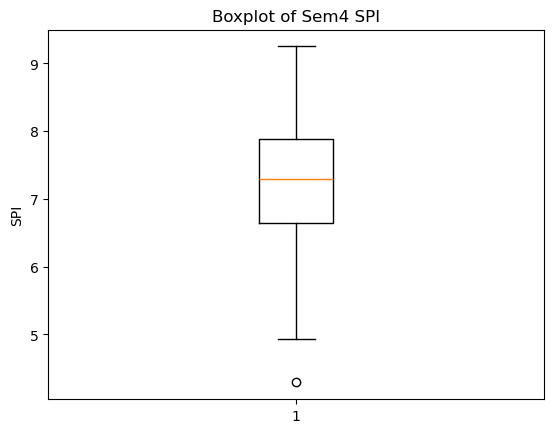

In [110]:
#13
import matplotlib.pyplot as plt
Q1 = df65['4th'].quantile(0.25)
Q3 = df65['4th'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df65[(df65['4th'] < lower) | (df65['4th'] > upper)]

print(outliers)
print("Number of outliers:", len(outliers))
plt.boxplot(df65['4th'])
plt.title("Boxplot of Sem4 SPI")
plt.ylabel("SPI")
plt.show()

In [2]:
#66
df66=pd.read_csv('movies.csv')
df66

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)


In [3]:
df66.columns

Index(['title_x', 'imdb_id', 'poster_path', 'wiki_link', 'title_y',
       'original_title', 'is_adult', 'year_of_release', 'runtime', 'genres',
       'imdb_rating', 'imdb_votes', 'story', 'summary', 'tagline', 'actors',
       'wins_nominations', 'release_date'],
      dtype='object')

In [5]:
#1
3df66[df66['year_of_release']==2019]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
6,Fraud Saiyaan,tt5013008,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Fraud_Saiyaan,Fraud Saiyaan,Fraud Saiyyan,0,2019,109,Comedy|Drama,4.2,504,Fraud Saiyyan is the story of a con artist in ...,Fraud Saiyyan is the story of a con artist in ...,NaN,Arshad Warsi|Saurabh Shukla|Flora Saini|Sara L...,NaN,18 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,Commando 3 (film),tt8983168,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Commando_3_(film),Commando 3,Commando 3,0,2019,133,Action|Thriller,5.7,2400,A mysterious man is on an impending mission to...,Commando 3 is a Hindi movie starring Vidyut Ja...,NaN,Vidyut Jammwal|Adah Sharma|Angira Dhar|Sumeet ...,NaN,NaN
77,Mardaani 2,tt5668770,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Mardaani_2,Mardaani 2,Mardaani 2,0,2019,103,Action|Drama|Thriller,7.4,8100,Shivani Shivaji Roy locks horns with the devil...,Shivani Shivaji Roy locks horns with the devil...,NaN,Rani Mukerji|Rajesh Sharma|Shruti Bapna|,NaN,NaN
78,Dabangg 3,tt7059844,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Dabangg_3,Dabangg 3,Dabangg 3,0,2019,160,Action,3.0,15000,Third installment of the Dabanng film series.,Third installment of the Dabanng film series.,NaN,Salman Khan|Sonakshi Sinha|Sudeep|Mahesh Manjr...,NaN,NaN
79,Good Newwz,tt8504014,NaN,https://en.wikipedia.org/wiki/Good_Newwz,Good Newwz,Good Newwz,0,2019,134,Comedy|Drama|Romance,6.9,16000,It is an upcoming Indian romantic comedy film ...,It is an upcoming Indian romantic comedy film ...,NaN,Akshay Kumar|Kareena Kapoor|Kiara Advani|Tisca...,NaN,NaN


In [7]:
#2
df66[df66['imdb_rating']>7].shape[0]

331

In [10]:
#3
df66[df66['imdb_votes']>20000][['title_x','story']]

,title_x,story
0,Uri: The Surgical Strike,Divided over five chapters the film chronicle...
11,Gully Boy,"Gully Boy is a film about a 22-year-old boy ""M..."
36,Kabir Singh,This Sandeep Vanga directorial is a remake of ...
74,Dil Bechara,A love story about two cancer patients.
88,Padmaavat,This fictional story is set in 13th century me...
...,...,...
1490,Devdas (2002 Hindi film),Devdas Mukherji is black-listed by his multi-m...
1565,Kabhi Khushi Kabhie Gham...,Yashvardhan Raichand lives a very wealthy life...
1567,Lagaan,This is the story about the resilience shown b...
1568,Lagaan,This is the story about the resilience shown b...


In [13]:
#4
df66[df66['year_of_release']==2018][['title_x','year_of_release']]

,title_x,year_of_release
4,Evening Shadows,2018
5,Soni (film),2018
16,Mard Ko Dard Nahi Hota,2018
17,Hamid (film),2018
20,Mere Pyare Prime Minister,2018
...,...,...
156,Rajma Chawal,2018
157,Zero (2018 film),2018
158,Simmba,2018
166,Thugs of Hindostan,2018


In [15]:
#5
df66[['title_x','wiki_link']]

,title_x,wiki_link
0,Uri: The Surgical Strike,https://en.wikipedia.org/wiki/Uri:_The_Surgica...
1,Battalion 609,https://en.wikipedia.org/wiki/Battalion_609
2,The Accidental Prime Minister (film),https://en.wikipedia.org/wiki/The_Accidental_P...
3,Why Cheat India,https://en.wikipedia.org/wiki/Why_Cheat_India
4,Evening Shadows,https://en.wikipedia.org/wiki/Evening_Shadows
...,...,...
1624,Tera Mera Saath Rahen,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...
1625,Yeh Zindagi Ka Safar,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...
1626,Sabse Bada Sukh,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh
1627,Daaka,https://en.wikipedia.org/wiki/Daaka


In [16]:
#67
df67=pd.read_csv('ipl-matches(1).csv')
df67

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [19]:
df67[(df67['WinningTeam']=='Gujarat Titans')&(df67['SuperOver']=='Y')].shape[0]

0

In [21]:
df67[(df67['WinningTeam']=='Royal Challengers Bangalore')&((df67['Team1']=='Kolkata Knight Riders')|(df67['Team2']=='Kolkata Knight Riders'))].shape[0]

14

In [23]:
df67[df67['WinningTeam']==df67['TossWinner']].shape[0]

489

In [25]:
df67[(df67['method']=='D/L')&(df67['WonBy']=='Wickets')].shape[0]

8

In [26]:
df67[(df67['WinningTeam']=='Rajasthan Royals')&(df67['TossWinner']=='Rajasthan Royals')].shape[0]

49

In [28]:
#68
data = {
"EmpID":[101,102,103,104,105],
"Dept":["IT","HR","IT","Finance","HR"],
"Salary":[60000,45000,80000,75000,50000],
"Age":[25,32,29,41,28]
}
df68=pd.DataFrame(data)
df68

,EmpID,Dept,Salary,Age
0,101,IT,60000,25
1,102,HR,45000,32
2,103,IT,80000,29
3,104,Finance,75000,41
4,105,HR,50000,28


In [35]:
df68=df68.sort_values( ['Dept','Salary'],ascending=[True,False])
df68

,EmpID,Dept,Salary,Age
3,104,Finance,75000,41
4,105,HR,50000,28
1,102,HR,45000,32
2,103,IT,80000,29
0,101,IT,60000,25


In [36]:
df68.sort_index(ascending=True)

,EmpID,Dept,Salary,Age
0,101,IT,60000,25
1,102,HR,45000,32
2,103,IT,80000,29
3,104,Finance,75000,41
4,105,HR,50000,28


In [38]:
#69
df69=df = pd.DataFrame({
"Student":["A","B","C","D"],
"Math":[70,45,90,60],
"Science":[75,40,85,55]
})
df69

,Student,Math,Science
0,A,70,75
1,B,45,40
2,C,90,85
3,D,60,55


In [42]:
df['Avg']=df69.apply(lambda x:(x['Math']+x['Science'])/2,axis=1)

In [43]:
df69

,Student,Math,Science,Avg
0,A,70,75,72.5
1,B,45,40,42.5
2,C,90,85,87.5
3,D,60,55,57.5


In [44]:
def grades(x):
    if x['Avg']>=80:
        return 'Ditinction'
    elif x['Avg']>=60:
        return 'First'
    else:
        return 'Second'
df69['Grade']=df69.apply(grades,axis=1)

In [45]:
df69

,Student,Math,Science,Avg,Grade
0,A,70,75,72.5,First
1,B,45,40,42.5,Second
2,C,90,85,87.5,Ditinction
3,D,60,55,57.5,Second


In [47]:
#70
df70= pd.DataFrame({
"Marks":["50","60","Absent","70","Absent"]
})
df70

,Marks
0,50
1,60
2,Absent
3,70
4,Absent


In [52]:
#1
df70['Marks']=df70['Marks'].replace('Absent',0)
df70

,Marks
0,50
1,60
2,0
3,70
4,0


In [54]:
#2
df70['Marks']=df70['Marks'].astype(int)

In [55]:
#3
df70.mean()

Marks    36.0
dtype: float64

In [57]:
df70[df70['Marks']>50].sha

,Marks
1,60
3,70
